<a href="https://colab.research.google.com/github/Arjunyadav0825/career-pulse-data-analyst/blob/main/career-pulse-data-analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [422]:
import pandas as pd
import numpy as np

np.random.seed(42)

skills = ["SQL","Excel","Python","Power BI","Tableau",
          "Statistics","AWS","Machine Learning","GenAI","Prompt Engineering"]

locations = ["Bangalore","Hyderabad","Pune","Delhi NCR",
             "Mumbai","Chennai","Remote"]

roles = ["Data Analyst","BI Analyst","Business Analyst","Product Analyst"]

experience = ["0-1","1-2","2-4","4-6"]

data = []

for i in range(1000):
    selected = np.random.choice(skills, size=np.random.randint(3,7), replace=False)

    data.append({
        "Job_ID": i+1,
        "Role": np.random.choice(roles),
        "Location": np.random.choice(locations),
        "Experience": np.random.choice(experience),
        "Salary_LPA": round(np.random.uniform(3,18),1),
        "SQL": int("SQL" in selected),
        "Excel": int("Excel" in selected),
        "Python": int("Python" in selected),
        "PowerBI": int("Power BI" in selected),
        "Tableau": int("Tableau" in selected),
        "Statistics": int("Statistics" in selected),
        "AWS": int("AWS" in selected),
        "MachineLearning": int("Machine Learning" in selected),
        "GenAI": int("GenAI" in selected),
        "PromptEngineering": int("Prompt Engineering" in selected)
    })

df = pd.DataFrame(data)

df.head()

,Job_ID,Role,Location,Experience,Salary_LPA,SQL,Excel,Python,PowerBI,Tableau,Statistics,AWS,MachineLearning,GenAI,PromptEngineering
0,1,Product Analyst,Mumbai,4-6,5.1,1,0,1,0,0,1,1,0,0,1
1,2,Product Analyst,Hyderabad,1-2,3.1,1,0,1,0,0,0,1,1,1,0
2,3,Business Analyst,Mumbai,0-1,4.0,0,1,0,0,1,1,0,0,0,0
3,4,Business Analyst,Delhi NCR,0-1,15.5,0,0,1,1,1,1,1,1,0,0
4,5,Business Analyst,Hyderabad,1-2,9.7,0,0,1,0,1,1,1,0,0,1


In [423]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job_ID             1000 non-null   int64  
 1   Role               1000 non-null   object 
 2   Location           1000 non-null   object 
 3   Experience         1000 non-null   object 
 4   Salary_LPA         1000 non-null   float64
 5   SQL                1000 non-null   int64  
 6   Excel              1000 non-null   int64  
 7   Python             1000 non-null   int64  
 8   PowerBI            1000 non-null   int64  
 9   Tableau            1000 non-null   int64  
 10  Statistics         1000 non-null   int64  
 11  AWS                1000 non-null   int64  
 12  MachineLearning    1000 non-null   int64  
 13  GenAI              1000 non-null   int64  
 14  PromptEngineering  1000 non-null   int64  
dtypes: float64(1), int64(11), object(3)
memory usage: 117.3+ KB


In [424]:
df.isnull().sum()

,0
Job_ID,0
Role,0
Location,0
Experience,0
Salary_LPA,0
SQL,0
Excel,0
Python,0
PowerBI,0
Tableau,0


In [425]:
df.duplicated().sum()

np.int64(0)

In [426]:
df = df.drop_duplicates()

In [427]:
total_jobs = len(df)
median_salary = df["Salary_LPA"].median()
avg_salary = df["Salary_LPA"].mean()
remote_jobs = (df["Location"] == "Remote").mean() * 100

print("Total Jobs:", total_jobs)
print("Median Salary:", round(median_salary,2), "LPA")
print("Average Salary:", round(avg_salary,2), "LPA")
print("Remote Jobs:", round(remote_jobs,2), "%")

Total Jobs: 1000
Median Salary: 10.1 LPA
Average Salary: 10.28 LPA
Remote Jobs: 15.6 %


In [428]:
skill_columns = [
    "SQL","Excel","Python","PowerBI","Tableau",
    "Statistics","AWS","MachineLearning","GenAI",
    "PromptEngineering"
]

skill_demand = df[skill_columns].sum().sort_values(ascending=False)

skill_demand

,0
AWS,471
GenAI,471
Excel,466
Python,457
Statistics,454
MachineLearning,438
Tableau,437
PromptEngineering,436
PowerBI,430
SQL,426


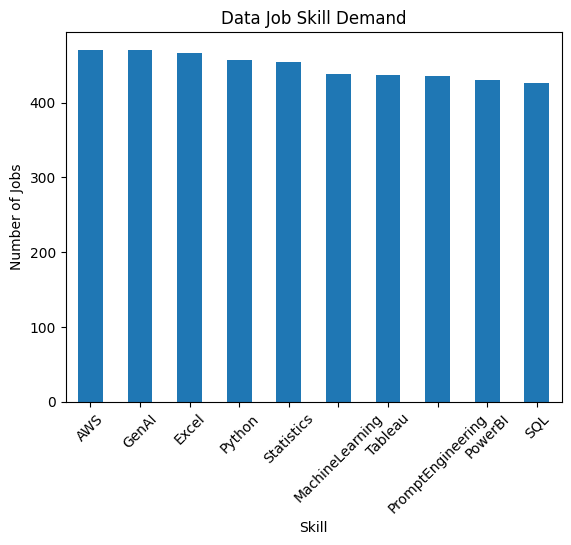

In [429]:
import matplotlib.pyplot as plt

skill_demand.plot(kind="bar")

plt.title("Data Job Skill Demand")
plt.xlabel("Skill")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

In [430]:
salary_by_skill = {}

for skill in skill_columns:
    salary_by_skill[skill] = df[df[skill] == 1]["Salary_LPA"].median()

salary_by_skill = pd.Series(salary_by_skill).sort_values(ascending=False)

salary_by_skill

,0
Tableau,10.90
Excel,10.35
PromptEngineering,10.35
MachineLearning,10.30
AWS,10.10
Statistics,10.10
PowerBI,10.05
Python,9.90
GenAI,9.40
SQL,9.35


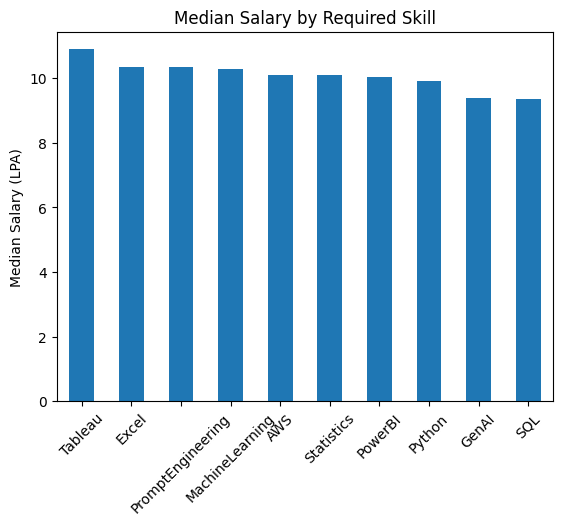

In [431]:
salary_by_skill.plot(kind="bar")

plt.title("Median Salary by Required Skill")
plt.ylabel("Median Salary (LPA)")
plt.xticks(rotation=45)
plt.show()

In [432]:
location_salary = df.groupby("Location")["Salary_LPA"].median().sort_values(ascending=False)

location_salary

,Salary_LPA
Location,
Remote,11.35
Chennai,10.95
Delhi NCR,9.95
Pune,9.90
Hyderabad,9.80
Mumbai,9.60
Bangalore,8.80


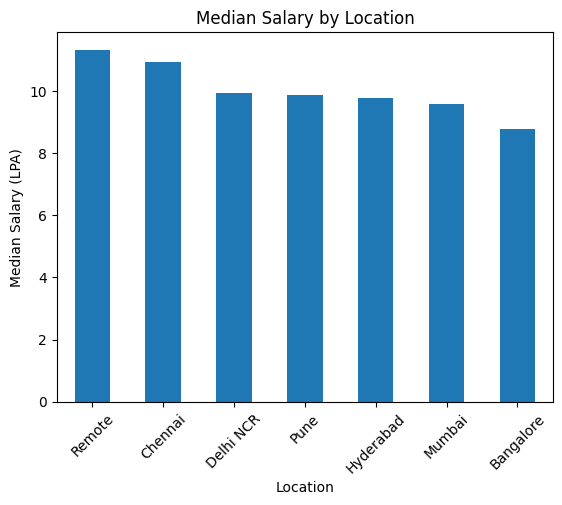

In [433]:
location_salary.plot(kind="bar")

plt.title("Median Salary by Location")
plt.ylabel("Median Salary (LPA)")
plt.xticks(rotation=45)
plt.show()

In [434]:
experience_salary = df.groupby("Experience")["Salary_LPA"].median()

experience_salary

,Salary_LPA
Experience,
0-1,9.2
1-2,10.3
2-4,11.8
4-6,9.9


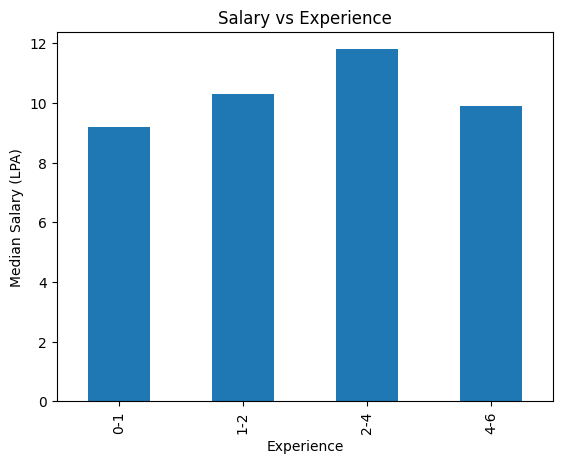

In [435]:
experience_salary.plot(kind="bar")

plt.title("Salary vs Experience")
plt.ylabel("Median Salary (LPA)")
plt.xlabel("Experience")
plt.show()

In [436]:
ai_demand = df[["GenAI","PromptEngineering","MachineLearning"]].sum()

ai_demand

,0
GenAI,471
PromptEngineering,436
MachineLearning,438


In [437]:
ai_percentage = df[["GenAI","PromptEngineering","MachineLearning"]].mean() * 100

ai_percentage.round(2)

,0
GenAI,47.1
PromptEngineering,43.6
MachineLearning,43.8


In [438]:
import sqlite3

conn = sqlite3.connect("careerpulse.db")

print("SQLite database connected successfully!")

SQLite database connected successfully!


In [439]:
df.to_sql(
    "jobs",
    conn,
    if_exists="replace",
    index=False
)

print("Data uploaded to SQLite!")

Data uploaded to SQLite!


In [440]:
query = """
SELECT *
FROM jobs
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,Job_ID,Role,Location,Experience,Salary_LPA,SQL,Excel,Python,PowerBI,Tableau,Statistics,AWS,MachineLearning,GenAI,PromptEngineering
0,1,Product Analyst,Mumbai,4-6,5.1,1,0,1,0,0,1,1,0,0,1
1,2,Product Analyst,Hyderabad,1-2,3.1,1,0,1,0,0,0,1,1,1,0
2,3,Business Analyst,Mumbai,0-1,4.0,0,1,0,0,1,1,0,0,0,0
3,4,Business Analyst,Delhi NCR,0-1,15.5,0,0,1,1,1,1,1,1,0,0
4,5,Business Analyst,Hyderabad,1-2,9.7,0,0,1,0,1,1,1,0,0,1
5,6,Data Analyst,Hyderabad,2-4,15.4,0,1,1,0,1,0,0,0,1,0
6,7,Product Analyst,Bangalore,4-6,7.4,0,1,1,1,0,1,0,0,0,0
7,8,Business Analyst,Hyderabad,0-1,16.7,0,1,0,1,1,1,0,0,1,0
8,9,Business Analyst,Bangalore,2-4,4.8,0,0,0,1,0,0,0,0,1,1
9,10,BI Analyst,Hyderabad,4-6,4.6,0,0,0,1,0,0,1,1,1,0


In [441]:
query = """
SELECT
    Location,
    COUNT(*) AS Job_Count,
    ROUND(AVG(Salary_LPA), 2) AS Average_Salary
FROM jobs
GROUP BY Location
ORDER BY Job_Count DESC;
"""

pd.read_sql_query(query, conn)

,Location,Job_Count,Average_Salary
0,Remote,156,11.05
1,Delhi NCR,144,10.13
2,Mumbai,143,10.02
3,Hyderabad,143,10.48
4,Bangalore,140,9.62
5,Chennai,138,10.43
6,Pune,136,10.16


In [442]:
query = """
SELECT
    SUM(SQL) AS SQL_Jobs,
    SUM(Excel) AS Excel_Jobs,
    SUM(Python) AS Python_Jobs,
    SUM(PowerBI) AS PowerBI_Jobs,
    SUM(GenAI) AS GenAI_Jobs
FROM jobs;
"""

pd.read_sql_query(query, conn)

,SQL_Jobs,Excel_Jobs,Python_Jobs,PowerBI_Jobs,GenAI_Jobs
0,426,466,457,430,471


In [443]:
query = """
SELECT COUNT(*) AS total_jobs
FROM jobs;
"""

pd.read_sql_query(query, conn)

,total_jobs
0,1000


In [444]:
query = """
SELECT DISTINCT Location
FROM jobs;
"""
pd.read_sql_query(query, conn)

,Location
0,Mumbai
1,Hyderabad
2,Delhi NCR
3,Bangalore
4,Pune
5,Chennai
6,Remote


In [445]:
query = """
SELECT ROUND(AVG(Salary_LPA), 2) AS avg_salary
FROM jobs;
"""
pd.read_sql_query(query, conn)

,avg_salary
0,10.28


In [446]:
query = """
SELECT Location, COUNT(*) AS jobs
FROM jobs
GROUP BY Location
ORDER BY jobs DESC;
"""
pd.read_sql_query(query, conn)

,Location,jobs
0,Remote,156
1,Delhi NCR,144
2,Mumbai,143
3,Hyderabad,143
4,Bangalore,140
5,Chennai,138
6,Pune,136


In [447]:
query = """
SELECT
    Location,
    ROUND(AVG(Salary_LPA),2) AS avg_salary
FROM jobs
GROUP BY Location
ORDER BY avg_salary DESC;
"""
pd.read_sql_query(query, conn)

,Location,avg_salary
0,Remote,11.05
1,Hyderabad,10.48
2,Chennai,10.43
3,Pune,10.16
4,Delhi NCR,10.13
5,Mumbai,10.02
6,Bangalore,9.62


In [448]:
query = """
SELECT
    Role,
    ROUND(AVG(Salary_LPA),2) AS avg_salary
FROM jobs
GROUP BY Role
ORDER BY avg_salary DESC;
"""
pd.read_sql_query(query, conn)

,Role,avg_salary
0,Product Analyst,10.66
1,Data Analyst,10.42
2,Business Analyst,10.33
3,BI Analyst,9.77


In [449]:
query = """
SELECT SUM(SQL) AS sql_jobs
FROM jobs;
"""
pd.read_sql_query(query, conn)

,sql_jobs
0,426


In [450]:
query = """
SELECT SUM(Python) AS python_jobs
FROM jobs;
"""
pd.read_sql_query(query, conn)

,python_jobs
0,457


In [451]:
query = """
SELECT COUNT(*) AS jobs
FROM jobs
WHERE SQL = 1
AND Python = 1;
"""
pd.read_sql_query(query, conn)

,jobs
0,188


In [452]:
query = """
SELECT COUNT(*) AS jobs
FROM jobs
WHERE SQL = 1
AND Python = 1
AND PowerBI = 1;
"""
pd.read_sql_query(query, conn)

,jobs
0,72


In [453]:
query = """
SELECT COUNT(*) AS ai_jobs
FROM jobs
WHERE GenAI = 1
   OR MachineLearning = 1
   OR PromptEngineering = 1;
"""
pd.read_sql_query(query, conn)

,ai_jobs
0,865


In [454]:
query = """
SELECT COUNT(*) AS high_salary_jobs
FROM jobs
WHERE Salary_LPA > 10;
"""
pd.read_sql_query(query, conn)

,high_salary_jobs
0,504


In [455]:
query = """
SELECT
    Role,
    ROUND(AVG(Salary_LPA),2) AS avg_salary
FROM jobs
GROUP BY Role
ORDER BY avg_salary DESC;
"""
pd.read_sql_query(query, conn)

,Role,avg_salary
0,Product Analyst,10.66
1,Data Analyst,10.42
2,Business Analyst,10.33
3,BI Analyst,9.77


In [456]:
skill_query = """
SELECT
    SUM(SQL) AS SQL,
    SUM(Excel) AS Excel,
    SUM(Python) AS Python,
    SUM(PowerBI) AS PowerBI,
    SUM(Tableau) AS Tableau,
    SUM(Statistics) AS Statistics,
    SUM(AWS) AS AWS,
    SUM(MachineLearning) AS MachineLearning,
    SUM(GenAI) AS GenAI,
    SUM(PromptEngineering) AS PromptEngineering
FROM jobs;
"""

skill_result = pd.read_sql_query(skill_query, conn)

skill_result

,SQL,Excel,Python,PowerBI,Tableau,Statistics,AWS,MachineLearning,GenAI,PromptEngineering
0,426,466,457,430,437,454,471,438,471,436


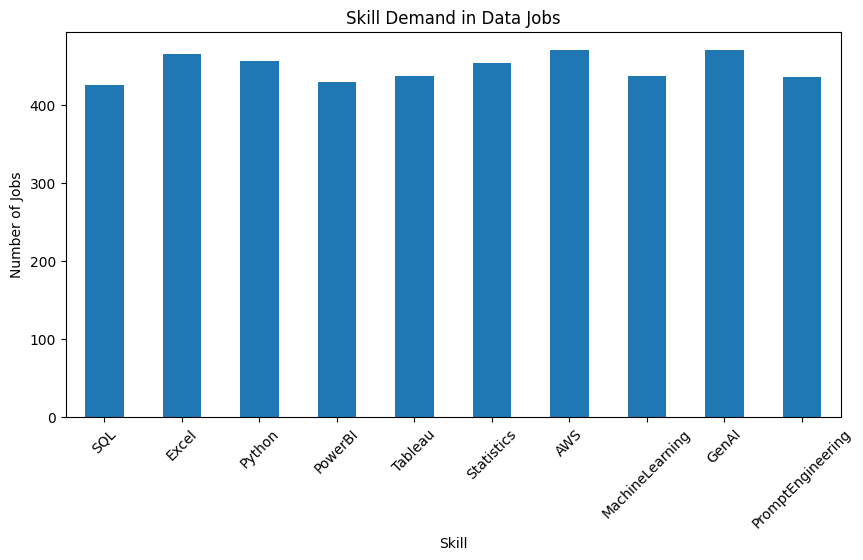

In [457]:
skill_result.T.plot(
    kind="bar",
    legend=False,
    figsize=(10,5)
)

plt.title("Skill Demand in Data Jobs")
plt.xlabel("Skill")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

In [458]:
location_query = """
SELECT
    Location,
    COUNT(*) AS Job_Count,
    ROUND(AVG(Salary_LPA),2) AS Average_Salary
FROM jobs
GROUP BY Location
ORDER BY Job_Count DESC;
"""

location_result = pd.read_sql_query(location_query, conn)

location_result

,Location,Job_Count,Average_Salary
0,Remote,156,11.05
1,Delhi NCR,144,10.13
2,Mumbai,143,10.02
3,Hyderabad,143,10.48
4,Bangalore,140,9.62
5,Chennai,138,10.43
6,Pune,136,10.16


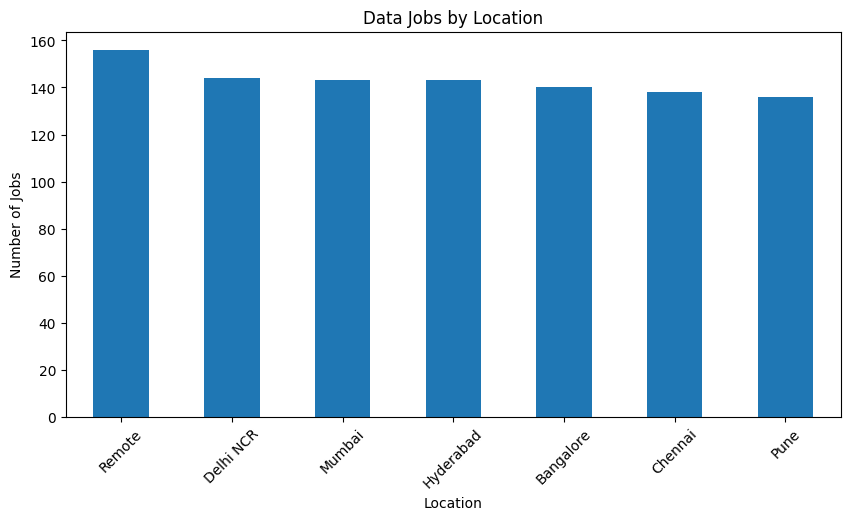

In [459]:
location_result.plot(
    x="Location",
    y="Job_Count",
    kind="bar",
    legend=False,
    figsize=(10,5)
)

plt.title("Data Jobs by Location")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

In [460]:
skill_query = """
SELECT
    SUM(SQL) AS SQL,
    SUM(Excel) AS Excel,
    SUM(Python) AS Python,
    SUM(PowerBI) AS PowerBI,
    SUM(Tableau) AS Tableau,
    SUM(Statistics) AS Statistics,
    SUM(AWS) AS AWS,
    SUM(MachineLearning) AS MachineLearning,
    SUM(GenAI) AS GenAI,
    SUM(PromptEngineering) AS PromptEngineering
FROM jobs;
"""

skill_result = pd.read_sql_query(skill_query, conn)

skill_result

,SQL,Excel,Python,PowerBI,Tableau,Statistics,AWS,MachineLearning,GenAI,PromptEngineering
0,426,466,457,430,437,454,471,438,471,436


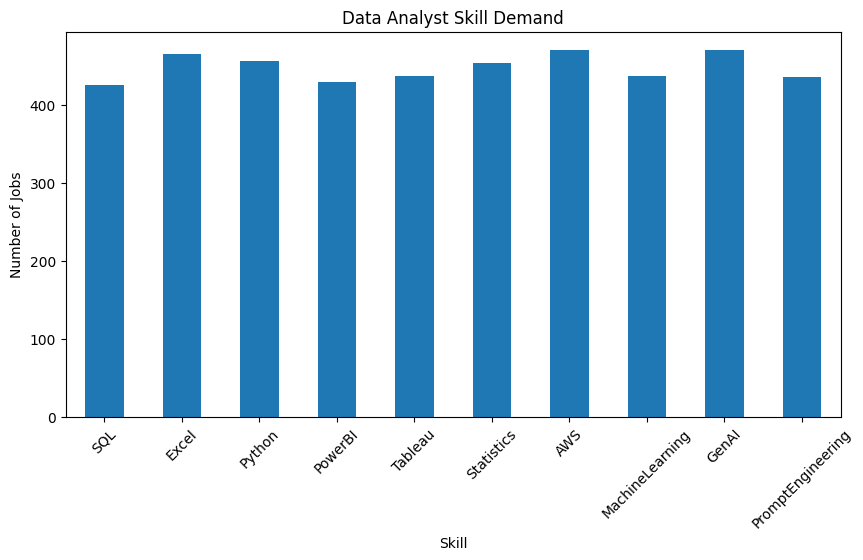

In [461]:
skill_result.T.plot(
    kind="bar",
    legend=False,
    figsize=(10,5)
)

plt.title("Data Analyst Skill Demand")
plt.xlabel("Skill")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

In [462]:
salary_skill = {}

for skill in skill_columns:
    salary_skill[skill] = df[df[skill] == 1]["Salary_LPA"].mean()

    salary_skill = pd.Series(salary_skill).sort_values(ascending=False)

    salary_skill

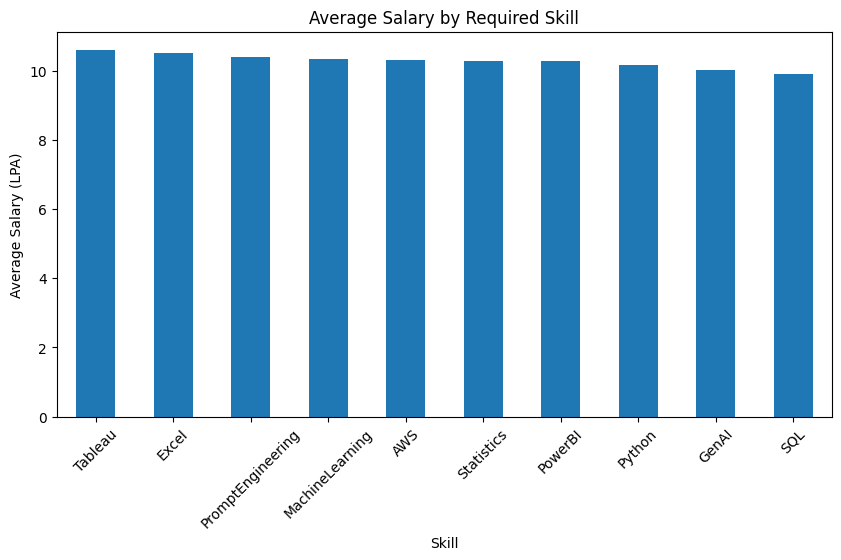

In [463]:
salary_skill.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Salary by Required Skill")
plt.xlabel("Skill")
plt.ylabel("Average Salary (LPA)")
plt.xticks(rotation=45)
plt.show()

In [464]:
location_salary = """
SELECT
    Location,
        COUNT(*) AS Job_Count,
            ROUND(AVG(Salary_LPA), 2) AS Avg_Salary
            FROM jobs
            GROUP BY Location
            ORDER BY Avg_Salary DESC;
            """

location_result = pd.read_sql_query(location_salary, conn)

location_result

,Location,Job_Count,Avg_Salary
0,Remote,156,11.05
1,Hyderabad,143,10.48
2,Chennai,138,10.43
3,Pune,136,10.16
4,Delhi NCR,144,10.13
5,Mumbai,143,10.02
6,Bangalore,140,9.62


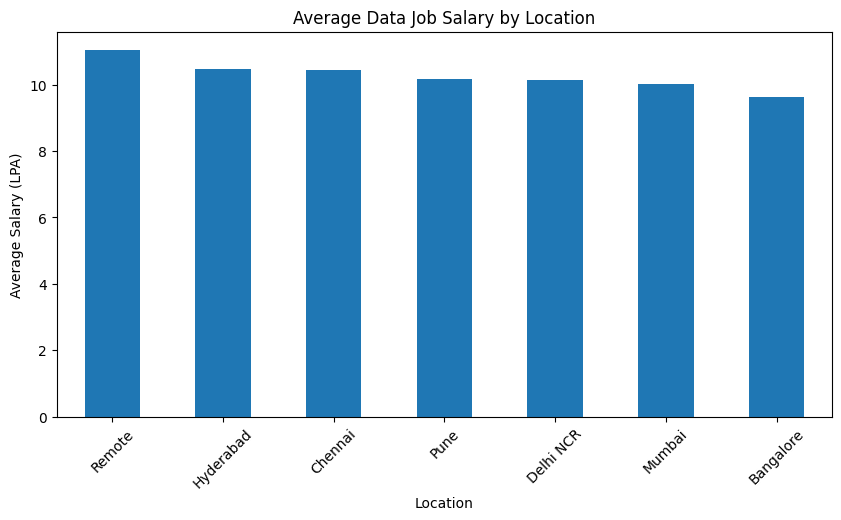

In [465]:
location_result.plot(
    x="Location",
    y="Avg_Salary",
    kind="bar",
    legend=False,
    figsize=(10,5)
)

plt.title("Average Data Job Salary by Location")
plt.xlabel("Location")
plt.ylabel("Average Salary (LPA)")
plt.xticks(rotation=45)
plt.show()

In [466]:
role_query = """
SELECT
    Role,
        COUNT(*) AS Job_Count,
            ROUND(AVG(Salary_LPA), 2) AS Avg_Salary
            FROM jobs
            GROUP BY Role
            ORDER BY Avg_Salary DESC;
            """

role_result = pd.read_sql_query(role_query, conn)

role_result

,Role,Job_Count,Avg_Salary
0,Product Analyst,240,10.66
1,Data Analyst,239,10.42
2,Business Analyst,252,10.33
3,BI Analyst,269,9.77


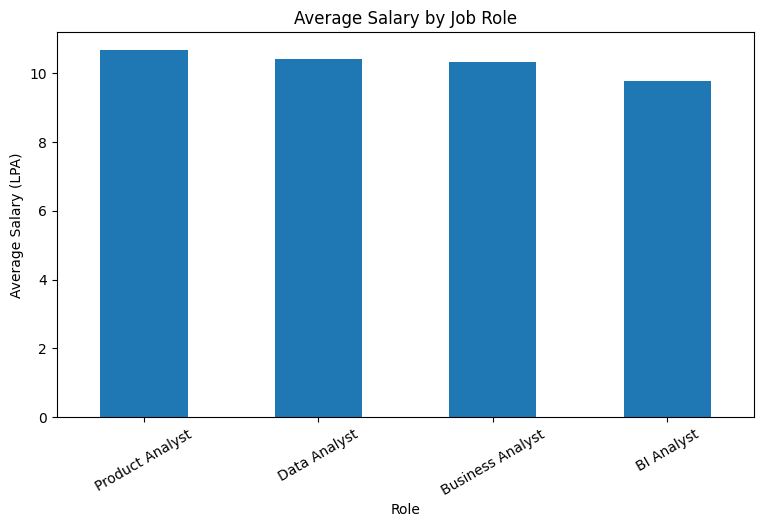

In [467]:
role_result.plot(
      x="Role",
          y="Avg_Salary",
              kind="bar",
                  legend=False,
                      figsize=(9,5)
                      )

plt.title("Average Salary by Job Role")
plt.xlabel("Role")
plt.ylabel("Average Salary (LPA)")
plt.xticks(rotation=30)
plt.show()

In [468]:
ai_query = """
SELECT
    SUM(GenAI) AS GenAI_Jobs,
        SUM(MachineLearning) AS ML_Jobs,
            SUM(PromptEngineering) AS PromptEngineering_Jobs
            FROM jobs;
            """
ai_result = pd.read_sql_query(ai_query, conn)
ai_result

,GenAI_Jobs,ML_Jobs,PromptEngineering_Jobs
0,471,438,436


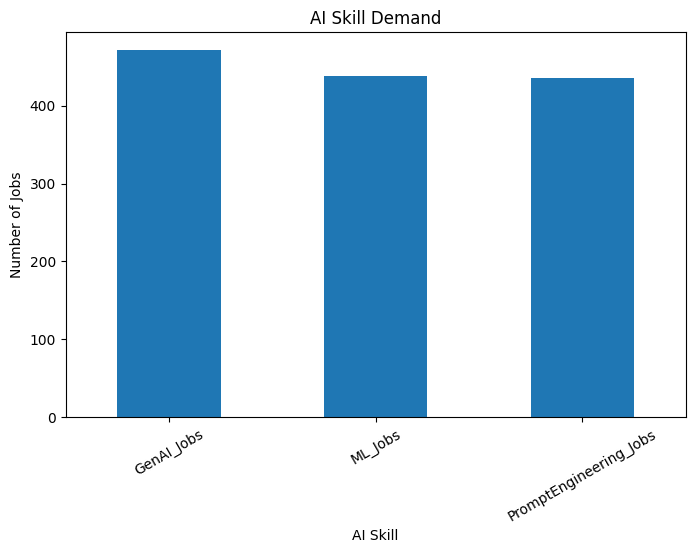

In [469]:
ai_result.T.plot(
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("AI Skill Demand")
plt.xlabel("AI Skill")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=30)
plt.show()

In [470]:
ai_jobs = df[
    (df["GenAI"] == 1) |
    (df["MachineLearning"] == 1) |
    (df["PromptEngineering"] == 1)
]

ai_percentage = (len(ai_jobs) / len(df)) * 100

print("AI-related Jobs:", len(ai_jobs))
print("AI-related Job Percentage:", round(ai_percentage, 2), "%")

AI-related Jobs: 865
AI-related Job Percentage: 86.5 %


In [471]:
query = """
SELECT
    ROUND(AVG(Salary_LPA), 2) AS Avg_Salary
FROM jobs
WHERE GenAI = 1;
"""

pd.read_sql_query(query, conn)

,Avg_Salary
0,10.02


In [472]:
query = """
SELECT
    ROUND(AVG(Salary_LPA), 2) AS Avg_Salary
FROM jobs
WHERE GenAI = 0;
"""

pd.read_sql_query(query, conn)

,Avg_Salary
0,10.51


In [473]:
skill_weights = (
    df[skill_columns].mean()
    .sort_values(ascending=False)
)

skill_weights

,0
AWS,0.471
GenAI,0.471
Excel,0.466
Python,0.457
Statistics,0.454
MachineLearning,0.438
Tableau,0.437
PromptEngineering,0.436
PowerBI,0.430
SQL,0.426


In [474]:
my_skills = [
    "SQL",
    "Excel",
    "Python",
    "PowerBI"
]

print("My Skills:", my_skills)

My Skills: ['SQL', 'Excel', 'Python', 'PowerBI']


In [475]:
total_weight = skill_weights.sum()

my_weight = skill_weights[
    skill_weights.index.isin(my_skills)
].sum()

skill_gap_score = (my_weight / total_weight) * 100

print("CareerPulse Skill Readiness Score:",
      round(skill_gap_score, 2), "%")

CareerPulse Skill Readiness Score: 39.66 %


In [476]:
missing_skills = [
    skill for skill in skill_columns
    if skill not in my_skills
]

print("Missing Skills:")
for skill in missing_skills:
    print("-", skill)

Missing Skills:
- Tableau
- Statistics
- AWS
- MachineLearning
- GenAI
- PromptEngineering


In [477]:
priority_skills = skill_weights[
    skill_weights.index.isin(missing_skills)
].sort_values(ascending=False)

priority_skills

,0
AWS,0.471
GenAI,0.471
Statistics,0.454
MachineLearning,0.438
Tableau,0.437
PromptEngineering,0.436


In [478]:
dashboard = pd.DataFrame({
    "Metric": [
        "Total Jobs",
        "Average Salary (LPA)",
        "Jobs Above 10 LPA",
        "AI Related Jobs",
        "SQL + Python Jobs",
        "SQL + Python + Power BI Jobs"
    ],
    "Value": [
        len(df),
        round(df["Salary_LPA"].mean(), 2),
        len(df[df["Salary_LPA"] > 10]),
        len(df[
            (df["GenAI"] == 1) |
            (df["MachineLearning"] == 1) |
            (df["PromptEngineering"] == 1)
        ]),
        len(df[(df["SQL"] == 1) & (df["Python"] == 1)]),
        len(df[
            (df["SQL"] == 1) &
            (df["Python"] == 1) &
            (df["PowerBI"] == 1)
        ])
    ]
})

dashboard

,Metric,Value
0,Total Jobs,1000.00
1,Average Salary (LPA),10.28
2,Jobs Above 10 LPA,504.00
3,AI Related Jobs,865.00
4,SQL + Python Jobs,188.00
5,SQL + Python + Power BI Jobs,72.00


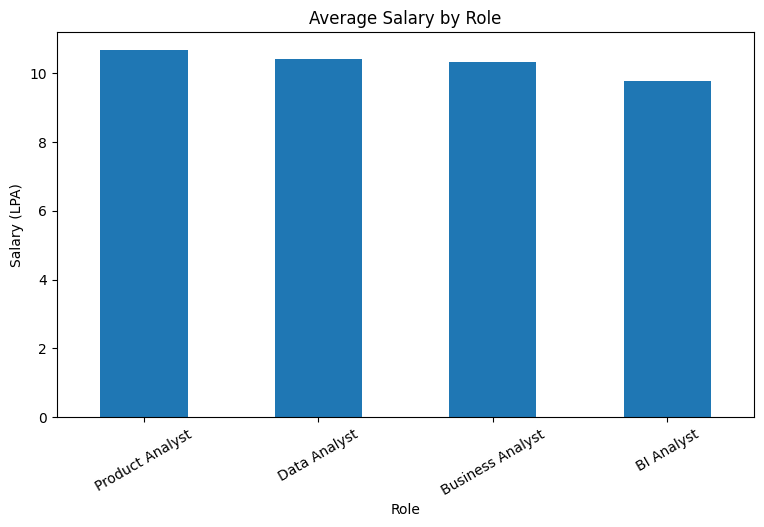

In [479]:
role_result.plot(
    x="Role",
    y="Avg_Salary",
    kind="bar",
    legend=False,
    figsize=(9,5)
)

plt.title("Average Salary by Role")
plt.ylabel("Salary (LPA)")
plt.xticks(rotation=30)
plt.show()

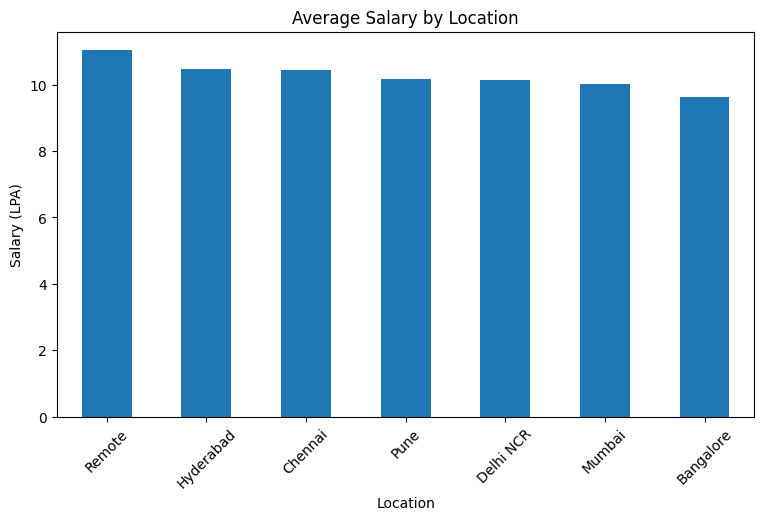

In [480]:
location_result.plot(
    x="Location",
    y="Avg_Salary",
    kind="bar",
    legend=False,
    figsize=(9,5)
)

plt.title("Average Salary by Location")
plt.ylabel("Salary (LPA)")
plt.xticks(rotation=45)
plt.show()

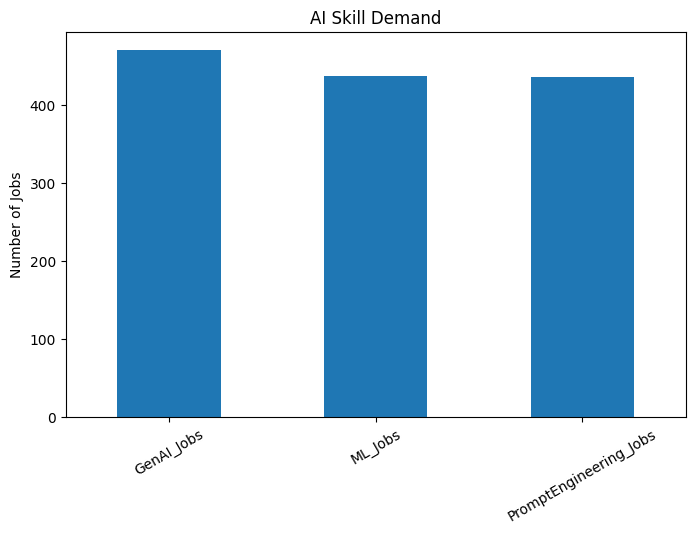

In [481]:
ai_result.T.plot(
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("AI Skill Demand")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=30)
plt.show()

In [482]:
plt.savefig("ai_skill_demand.png", dpi=150, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [483]:
plt.savefig("skill_demand.png", dpi=150, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [484]:
plt.savefig("salary_by_role.png", dpi=150, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [485]:
plt.savefig("salary_by_location.png", dpi=150, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>